# QCTO - Workplace Module

### Project Title: Evaluation of Vegetable Prices between January 2023 and January 2024
#### Done By: Tshepho Mabusela

© ExploreAI 2024

---

## Table of Contents

<a href=#BC> Background Context</a>

<a href=#one>1. Importing Packages</a>

<a href=#two>2. Data Collection and Description</a>

<a href=#three>3. Loading Data </a>

<a href=#four>4. Data Cleaning and Filtering</a>

<a href=#five>5. Exploratory Data Analysis (EDA)</a>

<a href=#six>6. Modeling </a>

<a href=#seven>7. Evaluation and Validation</a>

<a href=#eight>8. Final Model</a>

<a href=#nine>9. Conclusion and Future Work</a>

<a href=#ten>10. References</a>

---
 <a id="BC"></a>
## **Background Context**
<a href=#cont>Back to Table of Contents</a>

This project aims to evaluate the prices of different vegetables by determining whether or not the vegetable prices change by seasonality, in an attempt to provide cosumers/vegetable retailers with knowledge of when is the best season to purchase these vegetables.

---
<a href=#one></a>
## **Importing Packages**
<a href=#cont>Back to Table of Contents</a>

In [99]:
import pandas as pd # used for data manipulation and analysis
import matplotlib.pyplot as plt # used for static, animated, and interactive visualizations.
import seaborn as sns # used for drawing attractive and informative statistical graphics.
# import regression module
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np

---
<a href=#two></a>
## **Data Collection and Description**
<a href=#cont>Back to Table of Contents</a>

The dataset was downloaded from kaggle.com and will be read into a pandas dataframe and the dataset consists of a collection of prices of 10 different vegetables.
The prices are all numeric data and there are no blank values. The columns in the tabular data include Price dates, Bhindi(Ladies finger), Tomato, Onion, Potato, Brinjal, Garlic, Peas, Methi, Green Chilli, Elephant Yam (Suran) and the data consists of 287 rows and 11 columns.

---
<a href=#three></a>
## **Loading Data**
<a href=#cont>Back to Table of Contents</a>

In [2]:
#Please use code cells to code in and do not forget to comment your code.
data = pd.read_csv('./prices.csv')
data.head()

,Price Dates,Bhindi (Ladies finger),Tomato,Onion,Potato,Brinjal,Garlic,Peas,Methi,Green Chilli,Elephant Yam (Suran)
0,01-01-2023,35.0,18,22.0,20,30,50,25,8,45.0,25
1,02-01-2023,35.0,16,22.0,20,30,55,25,7,40.0,25
2,03-01-2023,35.0,16,21.0,20,30,55,25,7,40.0,25
3,04-01-2023,30.0,16,21.0,22,25,55,25,7,40.0,25
4,08-01-2023,35.0,16,20.0,21,25,55,22,6,35.0,25


In [9]:
data.shape

(287, 11)

##### The data consists of 287 Rows and 11 columns

---
<a href=#four></a>
## **Data Cleaning and Filtering**
<a href=#cont>Back to Table of Contents</a>

* **Purpose:** Prepare the data for analysis by cleaning and filtering.
* **Details:** Include steps for handling missing values, removing outliers, correcting errors, and possibly reducing the data (filtering based on certain criteria or features).
---

Data cleaning is a crucial step in data analysis as it ensures the data is accurate, consistent, and fit for its intended purpose. By minimizing errors and biases caused by incomplete or poorly formatted data, it helps generate reliable insights and conclusions, making it a vital part of any data-driven decision-making process.

In [13]:
# Create a copy of our dataframe, we are preserving the data in the original dataframe.
df_copy = data.copy()
df_copy.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Price Dates             287 non-null    object 
 1   Bhindi (Ladies finger)  287 non-null    float64
 2   Tomato                  287 non-null    int64  
 3   Onion                   287 non-null    float64
 4   Potato                  287 non-null    int64  
 5   Brinjal                 287 non-null    int64  
 6   Garlic                  287 non-null    int64  
 7   Peas                    287 non-null    int64  
 8   Methi                   287 non-null    int64  
 9   Green Chilli            287 non-null    float64
 10  Elephant Yam (Suran)    287 non-null    int64  
dtypes: float64(3), int64(7), object(1)
memory usage: 24.8+ KB


The above information shows that price Dates column has a object data type, we will convert this to date data type

In [14]:
# Convert the 'Price Dates' column to datetime format so that it is no longer an object data type
df_copy['Price Dates'] = pd.to_datetime(df_copy['Price Dates'], format = '%d-%m-%Y')

In [15]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287 entries, 0 to 286
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Price Dates             287 non-null    datetime64[ns]
 1   Bhindi (Ladies finger)  287 non-null    float64       
 2   Tomato                  287 non-null    int64         
 3   Onion                   287 non-null    float64       
 4   Potato                  287 non-null    int64         
 5   Brinjal                 287 non-null    int64         
 6   Garlic                  287 non-null    int64         
 7   Peas                    287 non-null    int64         
 8   Methi                   287 non-null    int64         
 9   Green Chilli            287 non-null    float64       
 10  Elephant Yam (Suran)    287 non-null    int64         
dtypes: datetime64[ns](1), float64(3), int64(7)
memory usage: 24.8 KB


The prices data consists of both float and int data types, we will standardize them by converting int data types to float.

In [17]:
"""
Ensure consistent data types for all variables 

We have 
    Bhindi (Ladies finger)
    Onion and
    Green Chilli
with inconsistent data types for some cases in these variables
    
""" 

df_copy['Bhindi (Ladies finger)'] = df_copy['Bhindi (Ladies finger)'].astype('float64')
df_copy['Tomato'] = df_copy['Tomato'].astype('float64')
df_copy['Potato'] = df_copy['Potato'].astype('float64')
df_copy['Brinjal'] = df_copy['Brinjal'].astype('float64')
df_copy['Garlic'] = df_copy['Garlic'].astype('float64')
df_copy['Peas'] = df_copy['Peas'].astype('float64')
df_copy['Methi'] = df_copy['Methi'].astype('float64')
df_copy['Elephant Yam (Suran)'] = df_copy['Elephant Yam (Suran)'].astype('float64')
df_copy['Onion'] = df_copy['Onion'].astype('float64')
df_copy['Green Chilli'] = df_copy['Green Chilli'].astype('float64')

##### Now, We check if we have any missing values

In [18]:
missing_values = df_copy.isnull().sum()
print(missing_values)

Price Dates               0
Bhindi (Ladies finger)    0
Tomato                    0
Onion                     0
Potato                    0
Brinjal                   0
Garlic                    0
Peas                      0
Methi                     0
Green Chilli              0
Elephant Yam (Suran)      0
dtype: int64


After evaluation of the above code output, It shows that we have no missing values.

In [6]:
# Identify duplicate rows
duplicates = df_copy.duplicated()
print("Duplicate Rows:\n", df_copy[duplicates])

Duplicate Rows:
 Empty DataFrame
Columns: [Price Dates, Bhindi (Ladies finger), Tomato, Onion, Potato, Brinjal, Garlic, Peas, Methi, Green Chilli, Elephant Yam (Suran)]
Index: []


After evaluation of the above code output, It shows that we have no duplicated rows.

As per observation, There are no missing values in our columns and no duplicated rows in our data.
If there were missing values in our columns, we would set a default value for those missing values. see example below

The following is how we would handle columns with missing values

In [7]:
# If Tomato column had missing values
tomato_mean = df_copy['Tomato'].mean()
df_copy['Tomato'] = df_copy['Tomato'].fillna(value=tomato_mean)

The following is how we would handle columns with error values

In [ ]:
# If there are errors within the dataset, we can skip the erroneous record with the following
# test_df = pd.read_csv('./prices.csv', error_bad_lines=False, warn_bad_lines=True)
# when loading the dataframe above, we skip the erroneous records and display messages to show which records are skipped.

TypeError: read_csv() got an unexpected keyword argument 'error_bad_lines'

The following is how we would filter data in our data frame

In [19]:
filter_condition = (df_copy['Brinjal'] > 30)
df_copy[filter_condition]

,Price Dates,Bhindi (Ladies finger),Tomato,Onion,Potato,Brinjal,Garlic,Peas,Methi,Green Chilli,Elephant Yam (Suran)
9,2023-01-22,45.0,16.0,18.0,22.0,40.0,65.0,25.0,9.0,40.0,35.0
10,2023-01-23,42.0,16.0,18.0,22.0,50.0,65.0,25.0,8.0,40.0,35.0
11,2023-01-24,45.0,16.0,16.0,22.0,60.0,65.0,28.0,15.0,35.0,30.0
12,2023-01-25,40.0,16.0,16.0,20.0,70.0,65.0,25.0,15.0,35.0,25.0
13,2023-01-27,35.0,16.0,17.0,17.0,50.0,65.0,25.0,15.0,35.0,25.0
...,...,...,...,...,...,...,...,...,...,...,...
282,2023-12-27,45.0,16.0,30.0,20.0,70.0,260.0,40.0,16.0,40.0,25.0
283,2023-12-28,45.0,16.0,30.0,20.0,70.0,260.0,30.0,20.0,45.0,25.0
284,2023-12-29,45.0,16.0,30.0,22.0,80.0,260.0,30.0,18.0,50.0,25.0
285,2023-12-31,45.0,16.0,26.0,20.0,60.0,250.0,40.0,16.0,50.0,40.0


In [20]:
df_copy.describe()

,Price Dates,Bhindi (Ladies finger),Tomato,Onion,Potato,Brinjal,Garlic,Peas,Methi,Green Chilli,Elephant Yam (Suran)
count,287,287.000000,287.000000,287.000000,287.000000,287.000000,287.000000,287.000000,287.000000,287.000000,287.000000
mean,2023-07-04 21:54:33.867595776,29.444251,16.006969,20.649826,18.585366,31.655052,133.101045,66.658537,20.383275,44.122404,28.797909
min,2023-01-01 00:00:00,17.000000,16.000000,8.000000,12.000000,14.000000,50.000000,22.000000,5.000000,0.130000,12.000000
25%,2023-04-06 12:00:00,22.000000,16.000000,12.000000,16.000000,25.000000,85.000000,40.000000,8.000000,35.000000,25.000000
50%,2023-07-04 00:00:00,27.500000,16.000000,16.000000,20.000000,30.000000,120.000000,60.000000,12.000000,40.000000,30.000000
75%,2023-10-01 12:00:00,33.000000,16.000000,25.000000,20.000000,35.000000,165.000000,80.000000,16.000000,50.000000,30.000000
max,2024-01-01 00:00:00,60.000000,18.000000,57.000000,24.000000,80.000000,290.000000,150.000000,2000.000000,90.000000,50.000000
std,NaN,8.124815,0.118056,11.711204,2.726238,11.725421,60.078331,33.302415,117.428417,12.796590,6.607973


---
<a href=#five></a>
## **Exploratory Data Analysis (EDA)**
<a href=#cont>Back to Table of Contents</a>

* **Purpose:** Explore and visualize the data to uncover patterns, trends, and relationships.
* **Details:** Use statistics and visualizations to explore the data. This may include histograms, box plots, scatter plots, and correlation matrices. Discuss any significant findings.
---


The EDA section is crucial as it establishes a foundation for effective data-driven decision-making.  
It offers a thorough understanding of the data, reveals insights and patterns, and informs the next steps in the analytical process, ensuring more robust and reliable results.

##### Let us start with line plots to visualize price trends for selected vegetables over time.

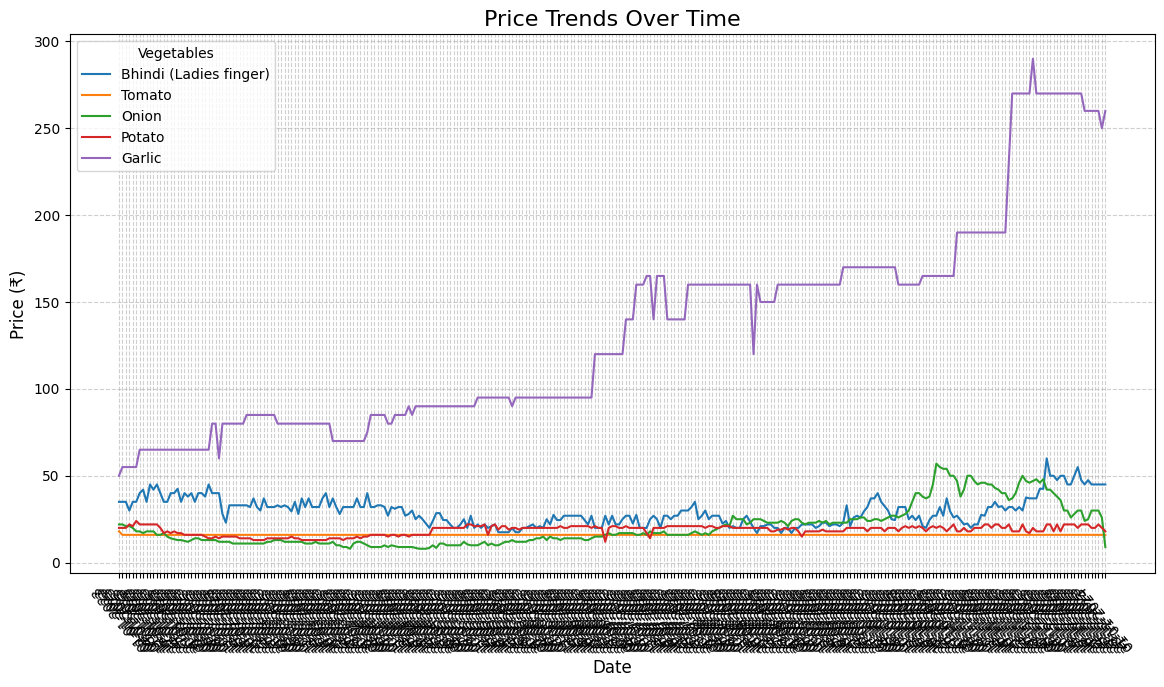

In [28]:
import matplotlib.dates as mdates

# Line plot for selected vegetables over time
vegetables = ['Bhindi (Ladies finger)', 'Tomato', 'Onion', 'Potato', 'Garlic']
plt.figure(figsize=(14, 7))

for veg in vegetables:
    plt.plot(data['Price Dates'], data[veg], label=veg)

plt.title('Price Trends Over Time', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (₹)', fontsize=12)
plt.legend(title="Vegetables", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(rotation=130)

# # Format dates
# plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1))  # Show ticks every month
# plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format: Jan 2024
# plt.xticks(rotation=45, ha='right')  # Rotate for better visibility

plt.show()


Here is a line plot illustrating the price trends of selected vegetables (Bhindi, Tomato, Onion, Potato, and Garlic) over time.

Observations:

There are visible fluctuations in prices for most vegetables.

Garlic appears to have a higher price range compared to others.

Some vegetables, such as Tomato and Potato, seem relatively stable over time.

### 6.1 Identifying outliers with box plots <a class="anchor" id="section_6_1"></a>

We need to identify and handle outliers in each variable otherwise we will end up with skewed data.

The box plots will give us a good understanding of the central tendency, variability, and the presence of any potential outliers. We will make use of the box plots to mainly identify potential outliers and to get an indication of the central tendency.


In [ ]:
# Create a copy of our dataframe, we are preserving the data in the copy dataframe.
df_copy_2 = df_copy.copy()

# Exclude the 'Price Dates' column because we don't need a box plot for dates.
# Exclude Methi because we will plot this vegetable seperately because of an outlier making graph difficult to view
df_variables = df_copy_2.drop(columns=['Price Dates', 'Methi'])

For the box plots, we want to review the distribution of the vegetable prices. We exclude Methi at first because this vegetable made the plot difficult to view

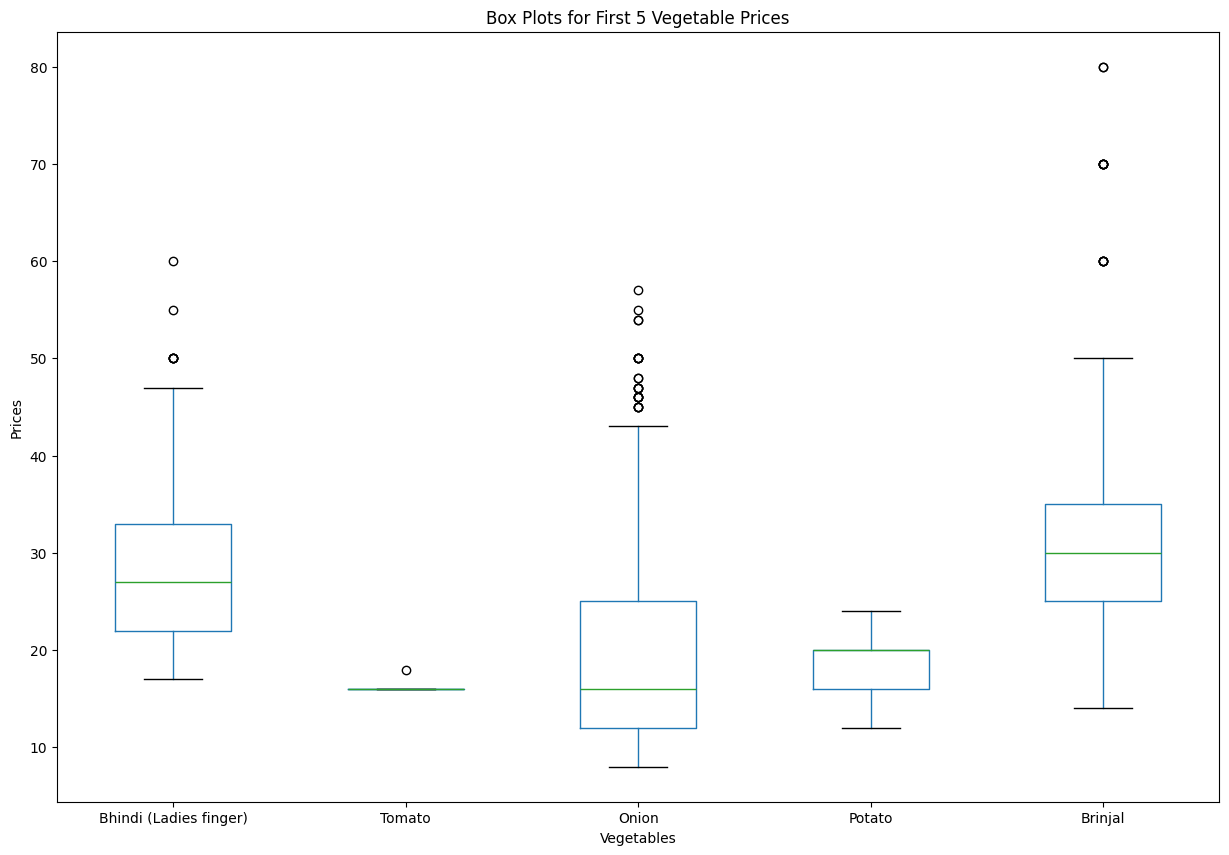

In [ ]:
# Select the first 5 variables
df_first_5 = df_variables.iloc[:, :5]

# Create a box plot for the first 5 variables
plt.figure(figsize=(15, 10))
df_first_5.boxplot(grid=False)
plt.title('Box Plots for First 5 Vegetable Prices')
plt.xlabel('Vegetables')
plt.ylabel('Prices')
plt.show()

_______________________________________________________________________________________________________________________________

##### General observations

##### Values in this section are approximate values, the exact values will be shown in the "Summary Statistics" section. 

* Variability: Bhindi and Onion have a larger spread in prices compared to Tomato and Potato, indicating more variability in their pricing.
* Outliers: Bhindi, Onion, and Brinjal have several outliers, suggesting occasional spikes in prices. We will investigate these outliers.
* Consistency: Tomato and Potato show less variability and fewer outliers, indicating more stable prices.
* Price Stability: Tomato and Potato prices are relatively stable, with fewer outliers and a smaller IQR.
* Price Variability: Bhindi, Onion, and Brinjal exhibit more variability and have outliers, indicating that their prices fluctuate more significantly.

##### Bhindi(Ladies finger)

* The box (interquartile range, IQR) represents the middle 50% of the data. The box for Bhindi(Ladies finger) for January 2023 to January 2024 spans from approximately 20 to 35.
* The price difference between the most expensive and least expensive Bhindi(Ladies finger) is approximately 30.
* The data is positively skewed because most of the Bhindi prices lie below the average price. 

##### Tomato

* The data is symmetrically distributed around the median which 16, this suggests that the mean is approximately 16.
* From January 2023 to January 2024, the price of tomato changes once from 16 to 18.

##### Onion

* The box (IQR) spans from approximately 12 to 30. Hence, the price range should be approximately 12 to 30.
* The data is positively skewed because most of the onion prices lie below the average price.

##### Potato

* The box (IQR) spans from 16 to 20, with the lowest potato price being approximately 12 and the highest price being approximately 24 for the period January 2023 to January 2024.
* The median is approximately 18 and closer to the top of the box.

##### Brinjals

* The median is approximately 30, and the box spans from about 25 to 35.
* The data  is positively skewed because most of the brinjals prices lie below the average price.

_______________________________________________________________________________________________________________________________


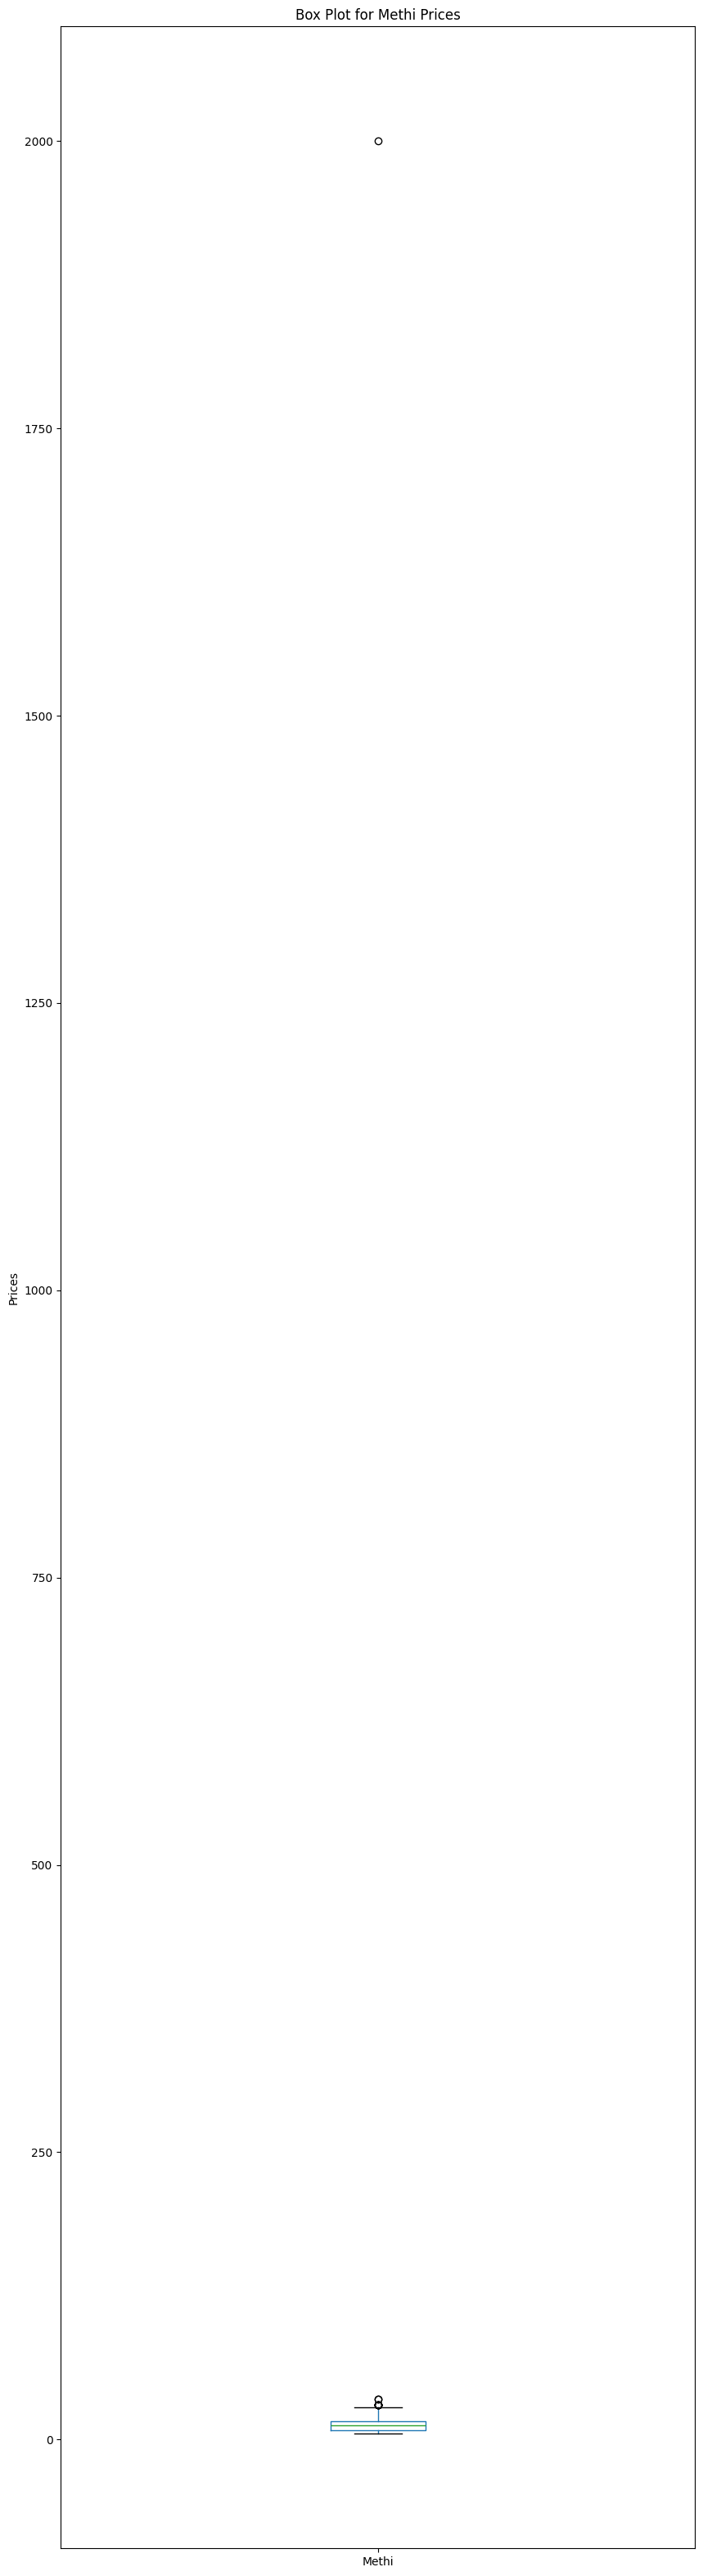

In [ ]:
# Create a box plot for 'Methi'
plt.figure(figsize=(10, 40))
df_copy_2.boxplot(column='Methi', grid=False)

# Set plot title and labels
plt.title('Box Plot for Methi Prices')
plt.ylabel('Prices')

# Show the plot
plt.show()

_______________________________________________________________________________________________________________________________

##### Methi

* Outliers: We have multiple outliers including one significant outlier being approximately 2000.
* Variability: Moderate variability within the IQR but a notable instance of extreme price fluctuation.
_______________________________________________________________________________________________________________________________


### 6.2 Identifying outliers with scatter plots <a class="anchor" id="section_6_2"></a>

In the next few steps we will plot scatter plots to spot the trends and patterns of the different vegetable prices. We will also be able to highlight the potential outliers we have just identified.

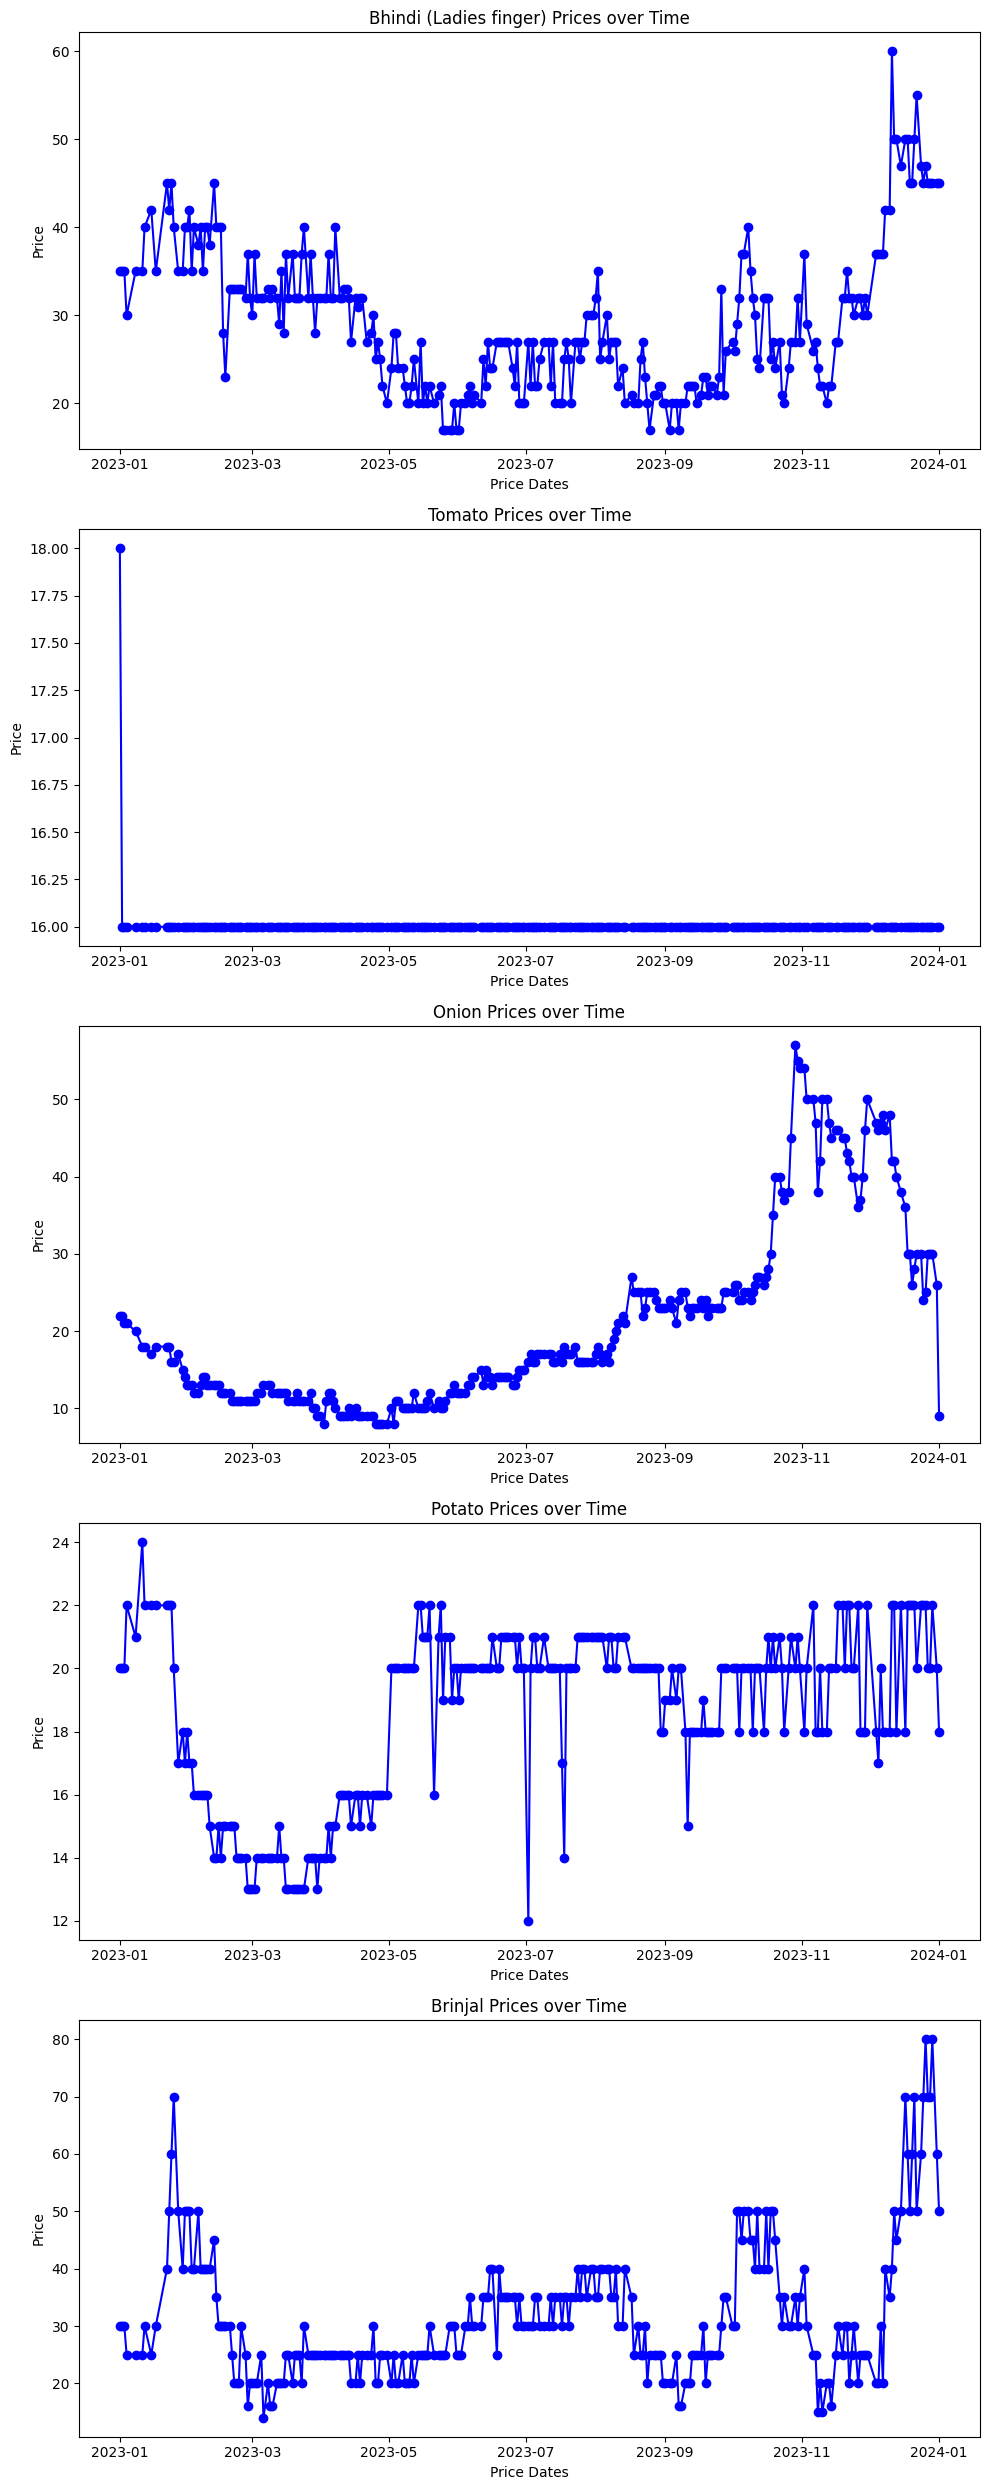

In [ ]:
# Split DataFrame into two parts
df_first = df_copy.iloc[:, :6]   # First 6 columns including 'Price Dates'

# Plotting the first group of vegetables
fig, axes_first = plt.subplots(nrows=len(df_first.columns) - 1, ncols=1, figsize=(10, 5 * (len(df_first.columns) - 1)))

for i, veg in enumerate(df_first.columns[1:]):  # Exclude 'Price Dates'
    ax = axes_first[i]
    ax.plot(df_first['Price Dates'], df_first[veg], marker='o', linestyle='-', color='b')
    ax.set_xlabel('Price Dates')
    ax.set_ylabel('Price')
    ax.set_title(f'{veg} Prices over Time')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

_______________________________________________________________________________________________________________________________

Based on the scatterplot analysis, it appears that there are no significant outliers in the data for vegetables Bhindi (Ladies finger), Tomato, Onion, Potato or Brinjals.  
The points are uniformly distributed around the trend line without any extreme values that would suggest anomalies.
_______________________________________________________________________________________________________________________________


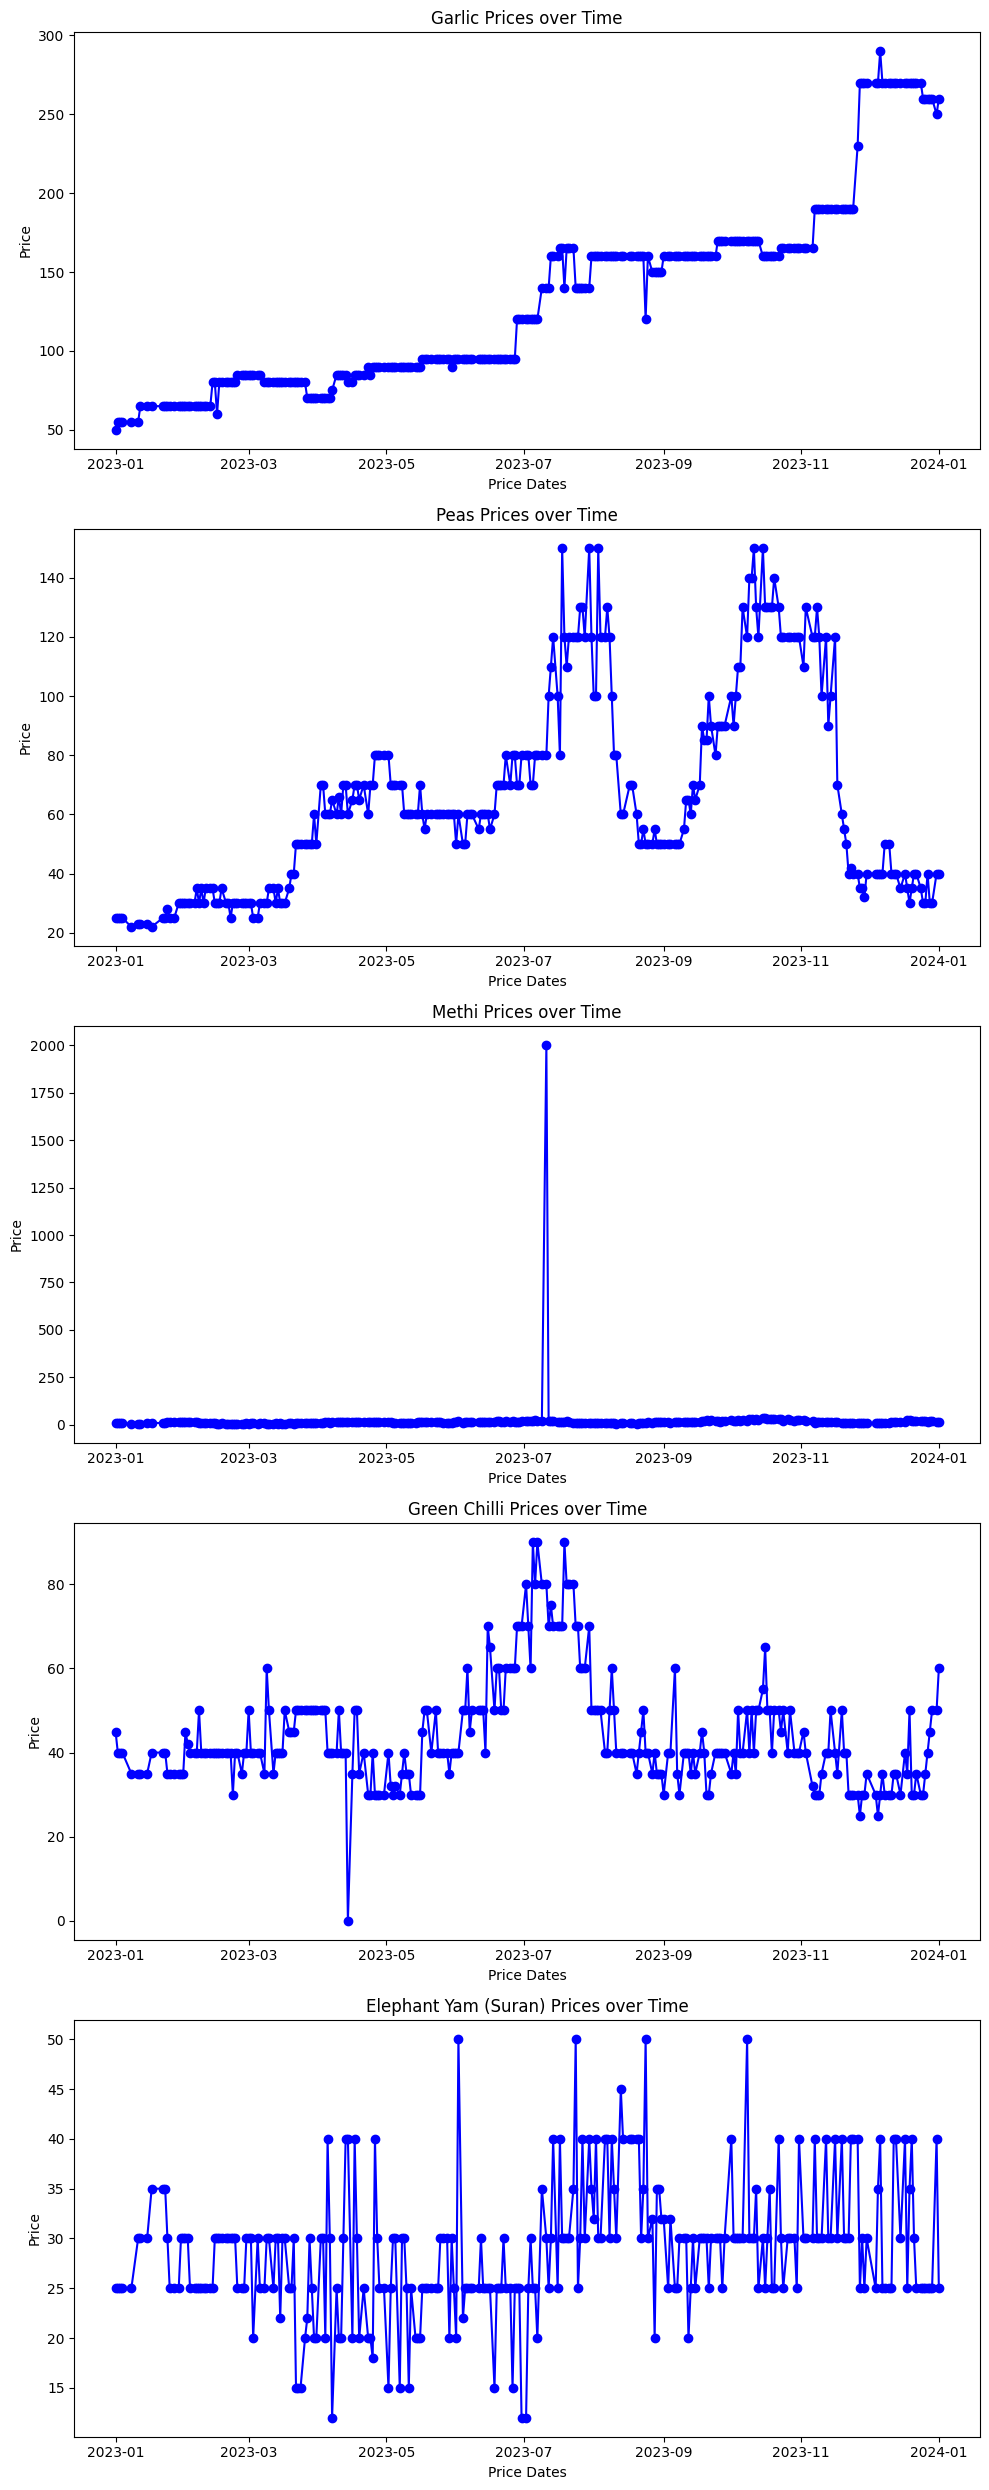

In [ ]:
#Exclude the first vegetables
df_second = df_copy.drop(columns=['Bhindi (Ladies finger)','Tomato','Onion','Potato','Brinjal'])

# Plotting the second group of vegetables
fig, axes_second = plt.subplots(nrows=len(df_second.columns) - 1, ncols=1, figsize=(10, 5 * (len(df_second.columns) - 1)))

for i, veg in enumerate(df_second.columns[1:]):  # Exclude 'Price Dates'
    ax = axes_second[i]
    ax.plot(df_second['Price Dates'], df_second[veg], marker='o', linestyle='-', color='b')
    ax.set_xlabel('Price Dates')
    ax.set_ylabel('Price')
    ax.set_title(f'{veg} Prices over Time')

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()

_______________________________________________________________________________________________________________________________

Based on the scatterplot analysis, it appears that there are no significant outliers in the data for vegetables Garlic, Peas,  or Elephant Yam (Suran).  
The points are uniformly distributed around the trend line without any extreme values that would suggest anomalies.

There are however outliers visible for vegetables Methi and Green Chilli. We will therefore need to further investigate and handle these outliers.
_______________________________________________________________________________________________________________________________


### 6.3 Identifying outliers with IQR <a class="anchor" id="section_6_3"></a>

In [ ]:
# Calculate Q1, Q3, and IQR
Q1 = df_copy.quantile(0.25)
Q3 = df_copy.quantile(0.75)
IQR = Q3 - Q1

# Determine outliers
outliers = (df_copy < (Q1 - 1.5 * IQR)) | (df_copy > (Q3 + 1.5 * IQR))

# Filter the original DataFrame to show outlier values
outlier_values = df_copy[outliers]

# Display outlier values
print("Outlier Values:")
print(outlier_values)

Outlier Values:
    Price Dates  Bhindi (Ladies finger)  Tomato  Onion  Potato  Brinjal  \
0           NaT                     NaN    18.0    NaN     NaN      NaN   
1           NaT                     NaN     NaN    NaN     NaN      NaN   
2           NaT                     NaN     NaN    NaN     NaN      NaN   
3           NaT                     NaN     NaN    NaN     NaN      NaN   
4           NaT                     NaN     NaN    NaN     NaN      NaN   
..          ...                     ...     ...    ...     ...      ...   
282         NaT                     NaN     NaN    NaN     NaN     70.0   
283         NaT                     NaN     NaN    NaN     NaN     70.0   
284         NaT                     NaN     NaN    NaN     NaN     80.0   
285         NaT                     NaN     NaN    NaN     NaN     60.0   
286         NaT                     NaN     NaN    NaN     NaN      NaN   

     Garlic  Peas  Methi  Green Chilli  Elephant Yam (Suran)  
0       NaN   NaN   

_____________________________________________________________________________________________________________________________


* As suspected, most of the shown potential outliers are actually not outliers. The prices seem to gradually increase/decrease and reaches an "outlier" price or even appear more than once in the data. The prices follow a clear trend. Therefore most values outside of the normal data parameters (outliers), will be kept as part of the data without any modifications.

* There are then two values we will classify as outliers. They significantly differ from the rest of the data
    
    Methi  with value of 2 000 and
    Green Chilli with value of 0.0
    
    
______________________________________________________________________________________________________________________________
 
 
 ### 6.4 Handling outliers <a class="anchor" id="section_6_4"></a>

In order to handle the outliers, we will replace the actual outliers with the relevant average vegetable price.

In [ ]:
# Replace the actual outliers with mean
Green_Chilli_outliers = (df_copy['Green Chilli'] == 0.0)
Methi_outliers = (df_copy['Methi'] == 2000)

Green_Chilli_mean = df_copy.loc[~Green_Chilli_outliers, 'Green Chilli'].mean()
Methi_mean = df_copy.loc[~Methi_outliers, 'Methi'].mean()

df_copy.loc[Green_Chilli_outliers, 'Green Chilli'] = Green_Chilli_mean
df_copy.loc[Methi_outliers, 'Methi'] = Methi_mean

# Display the modified DataFrame
print("Modified Data:")
print(df_copy.head(200))

Modified Data:
    Price Dates  Bhindi (Ladies finger)  Tomato  Onion  Potato  Brinjal  \
0    2023-01-01                      35      18     22      20       30   
1    2023-01-02                      35      16     22      20       30   
2    2023-01-03                      35      16     21      20       30   
3    2023-01-04                      30      16     21      22       25   
4    2023-01-08                      35      16     20      21       25   
..          ...                     ...     ...    ...     ...      ...   
195  2023-09-07                      17      16     24      20       16   
196  2023-09-08                      20      16     25      20       16   
197  2023-09-10                      20      16     25      18       20   
198  2023-09-11                      22      16     23      15       20   
199  2023-09-12                      22      16     22      18       20   

     Garlic  Peas  Methi  Green Chilli  Elephant Yam (Suran)  
0        50    25    

C:\Users\User\AppData\Local\Temp\ipykernel_12772\1562752615.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '44.27622377622377' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_copy.loc[Green_Chilli_outliers, 'Green Chilli'] = Green_Chilli_mean
C:\Users\User\AppData\Local\Temp\ipykernel_12772\1562752615.py:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '13.461538461538462' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_copy.loc[Methi_outliers, 'Methi'] = Methi_mean


### 6.5 Correlation to see the relationship between the vegetable prices  <a class="anchor" id="section_6_8"></a>

Correlation analysis is fundamental in data analysis because it quantifies relationships between variables, guides predictive modeling and decision-making, supports hypothesis testing, and validates research findings.

In [29]:
# Compute the correlation matrix
correlation_matrix = df_copy.corr(numeric_only=True)

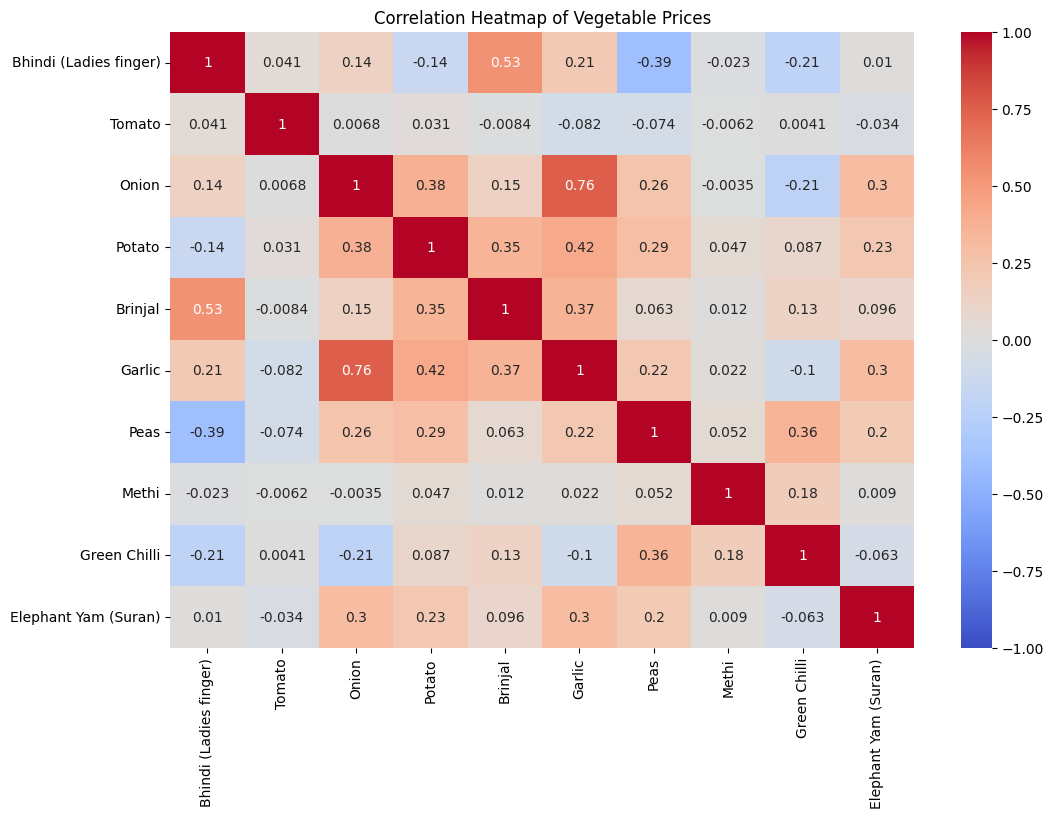

In [30]:
# Plot a heatmap of the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Vegetable Prices')
plt.show()

_______________________________________________________________________________________________________________________________

We see a strong positive correlation between Garlic and Onion prices which might be due to the fact that they are both in the allium vegetable family group.
We also see a moderate positive correlation between Bhindi and Brinjal prices.
The rest of the vegetables exhibit a weak positive / negative correlation to a no correlation to each other.

General observation is that most vegetable prices are not correlated to each other with exception of Garlic and Onion.

_______________________________________________________________________________________________________________________________

---
<a href=#six></a>
## **Modeling**
<a href=#cont>Back to Table of Contents</a>

* **Purpose:** Develop and train predictive or statistical models.
* **Details:** Describe the choice of models, feature selection and engineering processes, and show how the models are trained. Include code for setting up the models and explanations of the model parameters.
---


##### Since our dataset does not have a target column(prices column), we have transformed our data to have 3 columns, namely Price Dates, Vegetable and Vegetable Price and we have our features as vegetable and price dates and our target variable as Vegetable price. The name of the transformed vegetable data is named 'transformed_vegetable_prices'

Let us load the data from 'transformed_vegetable_prices' into a dataframe and start with modelling.

In [95]:
transformed_df = pd.read_csv('./transformed_vegetable_prices.csv');
transformed_df.head()

,Price Dates,Vegetable,Vegetable Price
0,01-01-2023,Bhindi (Ladies finger),35.0
1,02-01-2023,Bhindi (Ladies finger),35.0
2,03-01-2023,Bhindi (Ladies finger),35.0
3,04-01-2023,Bhindi (Ladies finger),30.0
4,08-01-2023,Bhindi (Ladies finger),35.0


In [97]:
transformed_df['Price Dates'] = pd.to_datetime(transformed_df['Price Dates'], format = '%d-%m-%Y')
# transformed_df['Vegetable'] = pd.to_datetime(transformed_df['Vegetable']).astype(str)

##### 1. Random Forest Model

In [104]:
# Initialize the encoder
encoder = OneHotEncoder(drop='first', sparse_output=False)

# Fit and transform the data
encoded_features = encoder.fit_transform(transformed_df[['Vegetable']])
encoded_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(['Vegetable']))

transformed_df['day'] = transformed_df['Price Dates'].dt.day
transformed_df['month'] = transformed_df['Price Dates'].dt.month
transformed_df['year'] = transformed_df['Price Dates'].dt.year

data_encoded = pd.concat([transformed_df.drop(columns=['Vegetable', 'Price Dates']), encoded_df], axis=1)

X = data_encoded.drop(columns = ['Vegetable Price'])
y = data_encoded['Vegetable Price'] 

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

r_model = RandomForestRegressor(n_estimators=100, random_state=42)

# # Train the model
r_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [105]:
# Get predictions
y_pred = r_model.predict(X_test)

# Compute RMSE
print("RMSE:", np.sqrt(mean_squared_error(y_test,y_pred)))
print("R2:", r2_score(y_test,y_pred))

RMSE: 10.18013578448698
R2: 0.9479727589091321


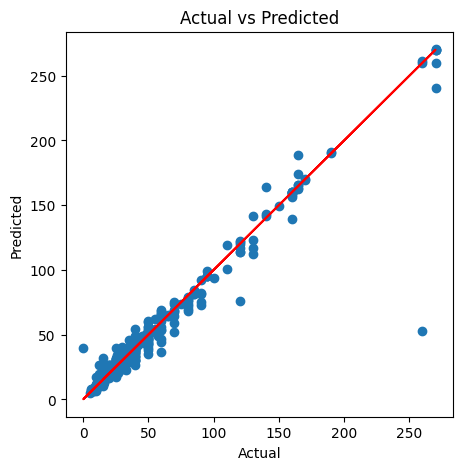

In [106]:
# Create figure and axes
f, ax = plt.subplots(figsize=(5,5))

# Plot actual vs. predicted values on axes
ax.set_title('Actual vs Predicted')
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.scatter(y_test,y_pred)
ax.plot(y_test,y_test,'r')
plt.show()

In [107]:
# 10 trees in forest
random_forest_model_1 = RandomForestRegressor(n_estimators=10, max_depth=5, random_state=42)

# 50 trees in forest
random_forest_model_2 = RandomForestRegressor(n_estimators=50, max_depth=5, random_state=42)

# 200 trees in forest
random_forest_model_3 = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

In [108]:
random_forest_model_1.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, n_estimators=10, random_state=42)

In [109]:
random_forest_model_2.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, n_estimators=50, random_state=42)

In [110]:
random_forest_model_3.fit(X_train, y_train)

RandomForestRegressor(max_depth=5, n_estimators=200, random_state=42)

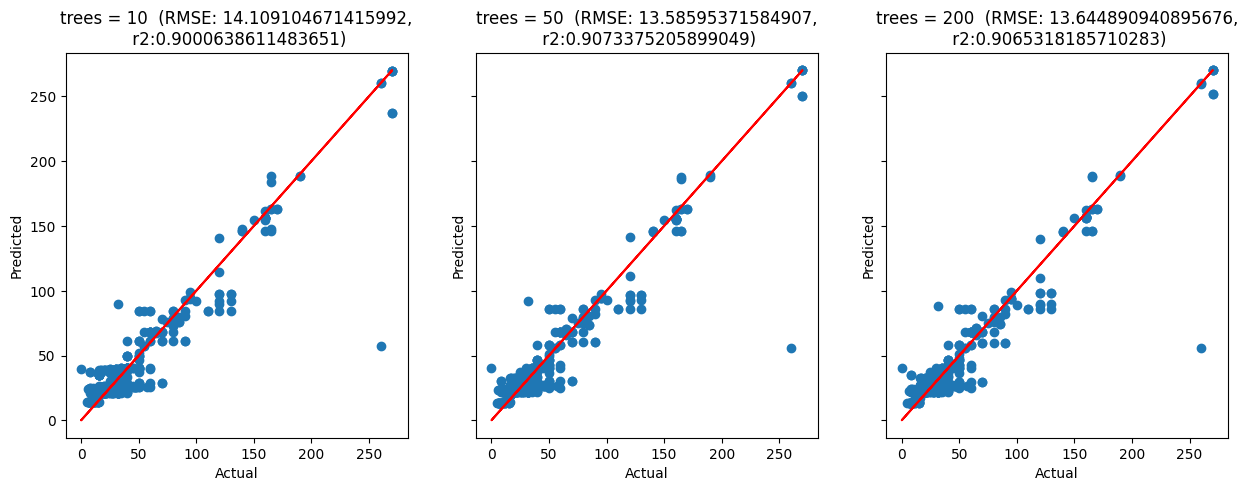

In [111]:
f, ax = plt.subplots(figsize=(15,5), nrows=1, ncols=3,sharey=True)

# Create list of titles and predictions to use in for loop
pred = [random_forest_model_1.predict(X_test), random_forest_model_2.predict(X_test), random_forest_model_3.predict(X_test)]
title = ['trees = 10', 'trees = 50', 'trees = 200']

# Loop through all axes to plot each model's results 
for i in range(3):
    rmse = np.sqrt(mean_squared_error(y_test, pred[i]))
    r2 = r2_score(y_test, pred[i])
    ax[i].set_title(title[i]+"  (RMSE: "+str(rmse)+ ",\n r2:"+str(r2)+")")
    # ax[i].set_title(title[i]+"  (RMSE: "+str(rmse)+ ")")
    ax[i].set_xlabel('Actual')
    ax[i].set_ylabel('Predicted')
    ax[i].plot(y_test,y_test,'r')
    ax[i].scatter(y_test,pred[i]) 

##### Linear Regression model.

In [120]:
# Initialize the Linear Regression model
l_model = LinearRegression()

# Train the model
l_model.fit(X_train, y_train)


# Make predictions on the test set
y_pred = l_model.predict(X_test)


---
<a href=#seven></a>
## **Evaluation and Validation**
<a href=#cont>Back to Table of Contents</a>

* **Purpose:** Evaluate and validate the effectiveness and accuracy of the models.
* **Details:** Present metrics used to evaluate the models, such as accuracy, precision, recall, F1-score, etc. Discuss validation techniques employed, such as cross-validation or train/test split.
---

Linear Regression model

In [119]:
# Evaluate the model (using Mean Squared Error as an example)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

# Optionally, you can also evaluate the model's performance using R^2 score
r2_score = l_model.score(X_test, y_test)
print(f"R^2 score: {r2_score}")

# Coefficients of the model (indicating the importance of each feature)
print(f"Coefficients: {l_model.coef_}")
print(f"Intercept: {l_model.intercept_}")

Mean Squared Error: 511.6664841590681
R^2 score: 0.7431316326400944
Coefficients: [-2.79404836e-02  2.52211677e+00  1.19103716e+01  1.42510065e+00
 -1.34134908e+00  1.00276991e+02  1.37275467e+01 -8.26660096e+00
 -9.29715765e+00  3.60306881e+01 -1.10614745e+01 -1.35729108e+01]
Intercept: -24080.837360257756


The R squred value is closer to 1, therefore our model is a moderately good fit.

Let's break down the results from the linear regression model:

1. **Mean Squared Error (MSE)**:  
   - The MSE value is **511.67**. This metric indicates the average squared difference between the predicted and actual values. Lower MSE means the model has better predictive accuracy. In this case, an MSE of 511.67 is somewhat large, depending on the scale of the target variable.

2. **R² Score**:  
   - The R² score is **0.7431**. This means that the model explains about **74.31%** of the variance in the dependent variable (target variable). An R² value closer to 1 suggests that the model fits the data well, while a value closer to 0 indicates a poor fit. In this case, an R² of 0.7431 indicates a moderately good fit, meaning the model does a reasonably good job of predicting the target variable.

3. **Coefficients**:  
   - The **coefficients** represent the weight of each feature in the linear regression equation. Each value tells you how much the dependent variable (target) is expected to change when that particular feature increases by 1 unit, assuming all other features remain constant.
   
   For example:
   - The coefficient for the first feature is **-0.0279**. This means that for every 1-unit increase in the first feature, the dependent variable is expected to decrease by 0.0279 units, holding all other features constant.
   - The coefficient for the second feature is **2.5221**. This means that for every 1-unit increase in the second feature, the dependent variable is expected to increase by 2.5221 units.
   - The rest of the coefficients have similar interpretations but with varying magnitudes and signs.

4. **Intercept**:  
   - The **intercept** is **-24080.84**. This is the predicted value of the dependent variable when all the independent variables (features) are equal to zero. In this case, it suggests that when all the features are zero, the dependent variable would have a value of approximately **-24080.84**.

### Summary:
- The model is moderately good, with an R² of 0.7431, explaining around 74% of the variance in the target variable.
- The MSE indicates a reasonable error in prediction, though the magnitude of this error will depend on the scale of your target variable.
- The coefficients tell you the relative influence of each feature on the target variable, with both positive and negative contributions depending on the feature's values.

---
<a href=#eight></a>
## **Final Model**
<a href=#cont>Back to Table of Contents</a>

* **Purpose:** Present the final model and its performance.
* **Details:** Highlight the best-performing model and discuss its configuration, performance, and why it was chosen over others.
---


The Random forest mode has the higher R squared value, therefore it's  a better fit fot data

---
<a href=#nine></a>
## **Conclusion and Future Work**
<a href=#cont>Back to Table of Contents</a>

* **Purpose:** Summarize the findings and discuss future directions.
* **Details:** Conclude with a summary of the results, insights gained, limitations of the study, and suggestions for future projects or improvements in methodology or data collection.
---


In [ ]:
#Please use code cells to code in and do not forget to comment your code.

---
<a href=#ten></a>
## **References**
<a href=#cont>Back to Table of Contents</a>

* **Purpose:** Provide citations and sources of external content.
* **Details:** List all the references and sources consulted during the project, including data sources, research papers, and documentation for tools and libraries used.
---

In [ ]:
#Please use code cells to code in and do not forget to comment your code.

## Additional Sections to Consider

* ### Appendix: 
For any additional code, detailed tables, or extended data visualizations that are supplementary to the main content.

* ### Contributors: 
If this is a group project, list the contributors and their roles or contributions to the project.
